# Cab Ride Price Prediction using  
**Objective**: Predict the price of Uber and Lyft rides using location, time, surge multiplier, and ride characteristics.

# Theoretical Introduction
Predicting the price of a cab ride is a supervised regression problem, where the goal is to estimate a continuous numerical value (the fare). Cab prices depend on multiple complex factors, including:

- Distance between pickup and dropoff

- Time of day

- Demand (surge multiplier)

- Type of service (UberX, Lyft XL, etc.)

These factors interact in non-linear ways. Therefore, the model must be able to capture non-linear relationships and feature interactions.

**Why XGBoost?**

XGBoost (Extreme Gradient Boosting):

- Excels on tabular datasets

- Handles missing data

- Captures non-linear relationships

- Prevents overfitting using regularization

- Fast and scalable

- Allows early stopping

XGBoost builds many small decision trees, each one correcting the previous model's errors (gradient boosting).

# Dataset Description
The dataset comes from Kaggle and contains ride prices from both Uber and Lyft. Important variables

- cab_type : Uber or Lyft

- name :vehicle category

- price :target variable

- distance : will be computed using geographic coordinates

- surge_multiplier:multiplier when demand is high

- timestamp :ride request time

- Pickup/dropoff latitude & longitude

- source / destination areas

In [34]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42

print("Loading and Merging Datasets...")
rides_path = '/kaggle/input/uber-lyft-cab-prices/cab_rides.csv' 
weather_path = '/kaggle/input/uber-lyft-cab-prices/weather.csv'

rides_df = pd.read_csv(rides_path)
weather_df = pd.read_csv(weather_path)

# Convert timestamps
rides_df['datetime'] = pd.to_datetime(rides_df['time_stamp'] / 1000, unit='s')
weather_df['datetime'] = pd.to_datetime(weather_df['time_stamp'], unit='s')

# Create 'merge_date' by rounding to nearest hour
rides_df['merge_date'] = rides_df['source'].astype(str) + " - " + rides_df['datetime'].dt.strftime('%Y-%m-%d %H:00:00')
weather_df['merge_date'] = weather_df['location'].astype(str) + " - " + weather_df['datetime'].dt.strftime('%Y-%m-%d %H:00:00')

# Merge datasets
weather_df = weather_df.drop_duplicates(subset=['merge_date'])
df = rides_df.merge(weather_df, on='merge_date', how='left')

# Drop rows without price
df = df.dropna(subset=['price'])

print(f"Merge Complete! Final dataset shape: {df.shape}")

Loading and Merging Datasets...
Merge Complete! Final dataset shape: (637976, 21)


Performing Exploratory Data Analysis...


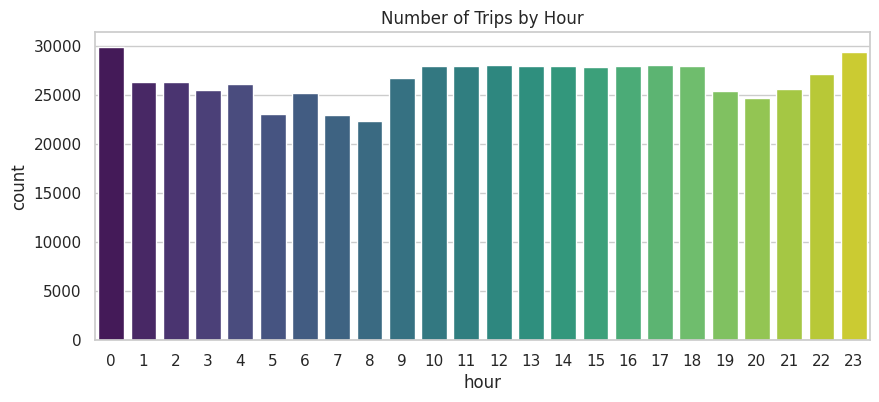

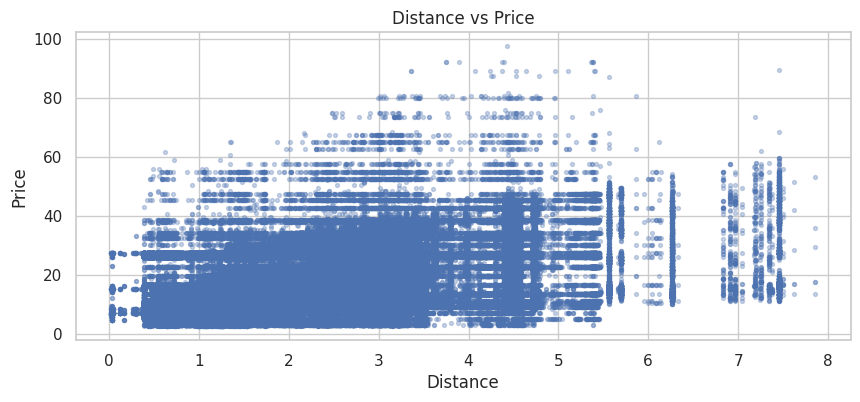

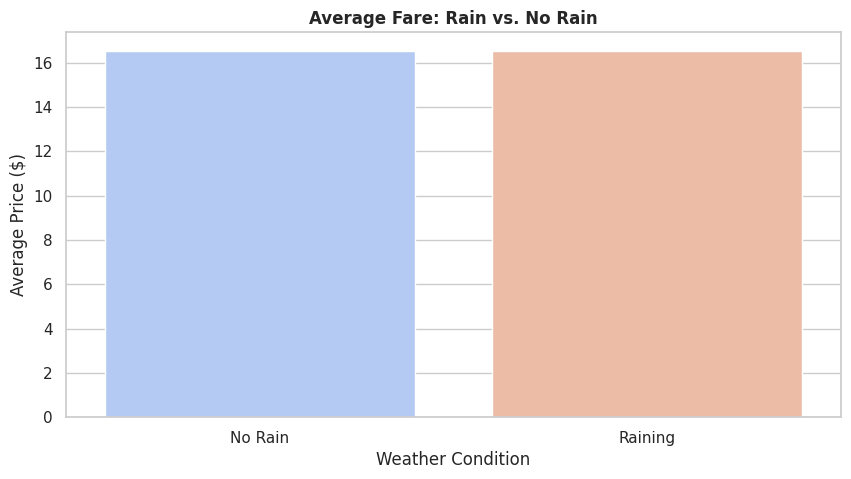

In [35]:
print("Performing Exploratory Data Analysis...")
df["hour"] = df["datetime_x"].dt.hour
df["date"] = df["datetime_x"].dt.date

# 1. Trips by Hour
plt.figure(figsize=(10,4))
sns.countplot(x=df["hour"], palette='viridis')
plt.title("Number of Trips by Hour")
plt.show()

# 2. Distance vs Price
plt.figure(figsize=(10,4))
plt.scatter(df["distance"], df["price"], alpha=0.3, s=8)
plt.xlabel("Distance")
plt.ylabel("Price")
plt.title("Distance vs Price")
plt.show()

# 3. Weather vs Price (Proving dynamic pricing using the 'rain' column)
# If rain is greater than 0, it's raining. Otherwise, it's clear.
df['weather_category'] = np.where(df['rain'].fillna(0) > 0, 'Raining', 'No Rain')

plt.figure(figsize=(10, 5))
sns.barplot(x='weather_category', y='price', data=df, errorbar=None, palette='coolwarm')
plt.title('Average Fare: Rain vs. No Rain', fontweight='bold')
plt.xlabel('Weather Condition')
plt.ylabel('Average Price ($)')
plt.show()

In [40]:
print("Engineering Features and Cleaning Data...")
df["haversine_km"] = df["distance"]

# Remove extreme outliers 
df = df[df["haversine_km"] < df["haversine_km"].quantile(0.995)]
df = df[df["price"] < df["price"].quantile(0.995)]

# Time features
df["day_of_week"] = df["datetime_x"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
df["is_rush_hour"] = df["hour"].isin([7,8,9,16,17,18]).astype(int)

# Impute missing numeric weather data
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = SimpleImputer(strategy="median").fit_transform(df[num_cols])

# Distance buckets
bins = [0,0.5,2,5,10,20,50,200]
labels = ["<0.5","0.5-2","2-5","5-10","10-20","20-50","50+"]
df["dist_bucket"] = pd.cut(df["haversine_km"], bins=bins, labels=labels)

# Encode categoricals (Added "name" back to the list!)
cat_cols = ["cab_type", "product_id", "name", "source", "destination", "dist_bucket", "weather_category"]
for col in cat_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

print("Feature Engineering Complete.")

Engineering Features and Cleaning Data...
Feature Engineering Complete.


In [43]:
print("Splitting Data into Train and Test sets...")
unique_dates = np.sort(df["date"].unique())

# Use last 20% of dates as test set
test_len = int(0.2 * len(unique_dates))
test_dates = unique_dates[-test_len:]

train_mask = df["date"].isin(unique_dates[:-test_len])
test_mask = df["date"].isin(test_dates)

# Drop non-predictive or duplicate text features before training
drop_cols = ["price", "time_stamp_x", "time_stamp_y", "datetime_x", "datetime_y", "date", "merge_date", "id", "location"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
y = df["price"]

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Splitting Data into Train and Test sets...
X_train shape: (510267, 20)
X_test shape: (113357, 20)


In [44]:
print("Training Baseline Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Baseline trained.")

Training Baseline Linear Regression...
Baseline trained.


In [45]:
print("Starting XGBoost Hyperparameter Tuning (GridSearchCV)...")
print("Note: This will take a few minutes to run on Kaggle.")

# Base model
xgb_base = XGBRegressor(random_state=RANDOM_STATE, objective='reg:squarederror')

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7]
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    cv=3, 
    scoring='neg_root_mean_squared_error', 
    verbose=1,
    n_jobs=-1
)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Extract the best model
best_xgb = grid_search.best_estimator_

print(f"\nBest Hyperparameters Found: {grid_search.best_params_}")

# Predict with best model
pred_xgb = best_xgb.predict(X_test)

Starting XGBoost Hyperparameter Tuning (GridSearchCV)...
Note: This will take a few minutes to run on Kaggle.
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Hyperparameters Found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


In [49]:
print("===== FINAL MODEL EVALUATION =====")

# Linear Regression Metrics
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = mean_squared_error(y_test, pred_lr, squared=False)
r2_lr = r2_score(y_test, pred_lr)

print("\n[ Baseline Linear Regression ]")
print(f"MAE : ${mae_lr:.2f}")
print(f"RMSE: ${rmse_lr:.2f}")
print(f"R2  :  {r2_lr:.4f}")

# XGBoost Metrics
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = mean_squared_error(y_test, pred_xgb, squared=False)
r2_xgb = r2_score(y_test, pred_xgb)

print("\n[ Tuned XGBoost Regressor ]")
print(f"MAE : ${mae_xgb:.2f}")
print(f"RMSE: ${rmse_xgb:.2f}")
print(f"R2  :  {r2_xgb:.4f}")

print("\n[ Model Comparison ]")
print(f"MAE improvement : ${mae_lr - mae_xgb:.2f}")
print(f"RMSE improvement: ${rmse_lr - rmse_xgb:.2f}")

===== FINAL MODEL EVALUATION =====

[ Baseline Linear Regression ]
MAE : $4.74
RMSE: $5.72
R2  :  0.5575

[ Tuned XGBoost Regressor ]
MAE : $1.05
RMSE: $1.56
R2  :  0.9671

[ Model Comparison ]
MAE improvement : $3.69
RMSE improvement: $4.16
